In [15]:
import json
import random
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Dict, List, Tuple, Optional
import networkx as nx  # For visualization if needed

# Load the FSTM instance from JSON
with open('instance_fstmv3.json', 'r') as f:
    instance = json.load(f)

events = instance['events']
rooms = instance['rooms']
teachers = instance['teachers']
groups = instance['groups']

# Create dictionaries for quick lookup
group_sizes = {g['name']: g['size'] for g in groups}
room_dict = {r['id']: r for r in rooms}
teacher_set = set(teachers)

# FIX CAP: Dynamique cap group sizes to max room type (prevent impossible)
max_amphi = max([r['capacity'] for r in rooms if r['type'] == 'Amphi'], default=0)
max_large = max([r['capacity'] for r in rooms if r['type'] == 'Large'], default=0)
max_small = max([r['capacity'] for r in rooms if r['type'] == 'Small'], default=0)

for g in groups:
    g_name = g['name']
    if g_name in ['TC S1', 'TC S3', 'TC GB S3']:  # Amphi
        g['size'] = min(g['size'], max_amphi)
    elif g_name == 'CI' or 'TD' in [e['name'] for e in events if e['group'] == g_name]:  # Large for TD/CI
        g['size'] = min(g['size'], max_large)
    elif g_name in ['MTU', 'Master IAII', 'MIASI']:  # Small
        g['size'] = min(g['size'], max_small)

group_sizes = {g['name']: g['size'] for g in groups}  # Reload fixed

print(f"Loaded {len(events)} events, {len(rooms)} rooms, {len(groups)} groups.")
print("Sample event:", events[0])
print(f"Fixed TC S1 size: {group_sizes.get('TC S1', 'N/A')} (max Amphi: {max_amphi})")
feasible_tc = [r['name'] for r in rooms if r['capacity'] >= group_sizes['TC S1'] and r['type'] == 'Amphi']
print(f"Feasible rooms for TC S1: {feasible_tc}")

Loaded 34 events, 34 rooms, 22 groups.
Sample event: {'id': 0, 'name': 'TC S1', 'group': 'TC S1', 'teacher': 'MOHSINE HACHKAR', 'duration_slots': 1, 'min_capacity': 400, 'preferred_room_type': 'Amphi'}
Fixed TC S1 size: 400 (max Amphi: 400)
Feasible rooms for TC S1: ['A1', 'A2', 'A4']


In [16]:
# Define core classes

class TimeSlot:
    def __init__(self, day: str, slot: int):
        self.day = day  # e.g., 'Monday'
        self.slot = slot  # 0: morning1, 1: morning2, etc.

    def __hash__(self):
        return hash((self.day, self.slot))

    def __eq__(self, other):
        return self.day == other.day and self.slot == other.slot

class Assignment:
    def __init__(self, event_id: int, time: TimeSlot, room_id: int, teacher: Optional[str] = None):
        self.event_id = event_id
        self.time = time
        self.room_id = room_id
        self.teacher = teacher

class Timetable:
    def __init__(self, events: List[dict]):
        self.assignments: List[Assignment] = []
        self.events = events
        self.days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
        self.slots_per_day = 4  # Based on FSTM schedule
        self.total_slots = len(self.days) * self.slots_per_day

    def add_assignment(self, event_id: int, time: TimeSlot, room_id: int, teacher: Optional[str] = None):
        self.assignments.append(Assignment(event_id, time, room_id, teacher))

    def get_schedule(self) -> Dict:
        # Group by time slot
        schedule = defaultdict(list)
        for ass in self.assignments:
            key = (ass.time.day, ass.time.slot)
            schedule[key].append({
                'event': self.events[ass.event_id]['name'],
                'room': room_dict[ass.room_id]['name'],
                'teacher': ass.teacher,
                'group': self.events[ass.event_id]['group']
            })
        return dict(schedule)

# Initialize timetable
timetable = Timetable(events)

In [17]:
def evaluate_fitness(timetable: Timetable, instance: dict, W_H: float = 1000.0, W_S: float = 1.0) -> float:
    events = instance['events']
    hard_penalty = 0
    soft_penalty = 0

    # Penalty for unassigned events
    assigned_events = set(ass.event_id for ass in timetable.assignments)
    unassigned = len(events) - len(assigned_events)
    hard_penalty += unassigned * 1000

    # Hard: Overlaps
    slot_occupancy = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    for ass in timetable.assignments:
        slot = (ass.time.day, ass.time.slot)
        room = ass.room_id
        teacher = ass.teacher or 'none'
        group = events[ass.event_id]['group']

        for cat, key in [('room', room), ('teacher', teacher), ('group', group)]:
            if slot_occupancy[slot][cat][key] > 0:
                hard_penalty += 1
            slot_occupancy[slot][cat][key] += 1

    # Hard: Capacity + Surcap Flag
    max_amphi = max([r['capacity'] for r in rooms if r['type'] == 'Amphi'], default=0)
    max_large = max([r['capacity'] for r in rooms if r['type'] == 'Large'], default=0)
    max_small = max([r['capacity'] for r in rooms if r['type'] == 'Small'], default=0)
    for ass in timetable.assignments:
        event = events[ass.event_id]
        group_size = group_sizes.get(event['group'], 0)
        room_cap = room_dict[ass.room_id]['capacity']
        room_type = room_dict[ass.room_id]['type']
        max_type = max_amphi if room_type == 'Amphi' else (max_large if room_type == 'Large' else max_small)
        if room_cap < group_size:
            diff = group_size - room_cap
            hard_penalty += diff * 20  # Augmenté
        if group_size > max_type:
            hard_penalty += 500  # Flag surcap impossible

    # Hard: Room type
    for ass in timetable.assignments:
        event = events[ass.event_id]
        room_type = room_dict[ass.room_id]['type']
        preferred = event.get('preferred_room_type', 'Any')
        if room_type != preferred:
            hard_penalty += 1

    # Hard: Exam conflicts
    exams = [e for e in events if e.get('is_exam', False)]
    for exam in exams:
        exam_ass = next((a for a in timetable.assignments if a.event_id == exam['id']), None)
        if exam_ass:
            conflicting = [a for a in timetable.assignments if a.event_id != exam['id'] and
                           events[a.event_id].get('is_exam', False) and a.time == exam_ass.time]
            hard_penalty += len(conflicting)

    # Soft: Gaps + Contiguïté (renforcé *0.6)
    group_slots = defaultdict(list)
    for ass in timetable.assignments:
        group = events[ass.event_id]['group']
        day_idx = timetable.days.index(ass.time.day)
        global_slot = day_idx * timetable.slots_per_day + ass.time.slot
        group_slots[group].append(global_slot)

    for group, slots in group_slots.items():
        total_possible = timetable.total_slots
        gaps = total_possible - len(slots)
        soft_penalty += gaps * 0.6
        if len(slots) > 1:
            sorted_slots = sorted(slots)
            contig_viol = sum(sorted_slots[i+1] - sorted_slots[i] > 1 for i in range(len(sorted_slots)-1))
            soft_penalty += contig_viol * 0.6

    # Soft: Preferences
    for ass in timetable.assignments:
        event = events[ass.event_id]
        if event.get('preferred_day') and event['preferred_day'] != ass.time.day:
            soft_penalty += 1
        if event.get('preferred_time') == 'afternoon' and ass.time.slot < 2:
            soft_penalty += 0.5

    # Soft: Balance load (*3)
    day_load = defaultdict(int)
    for ass in timetable.assignments:
        day_load[ass.time.day] += 1
    if day_load:
        max_load = max(day_load.values())
        min_load = min(day_load.values())
        imbalance = (max_load - min_load) * 3
        soft_penalty += imbalance

    total_fitness = W_H * hard_penalty + W_S * soft_penalty
    return total_fitness

# Test empty
empty_tt = Timetable(events)
print("Fitness of empty timetable:", evaluate_fitness(empty_tt, instance))

Fitness of empty timetable: 34000000.0


In [18]:
def generate_initial_timetable(events: List[dict], rooms: List[dict], teachers: List[str]) -> Timetable:
    tt = Timetable(events)
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    for event in events:
        day = random.choice(days)
        slot = random.randint(0, 3)
        time = TimeSlot(day, slot)
        group_size = group_sizes[event['group']]
        preferred_type = event.get('preferred_room_type', 'Any')
        feasible_rooms = [r['id'] for r in rooms if r['capacity'] >= group_size and
                          (preferred_type == 'Any' or r['type'] == preferred_type)]
        if not feasible_rooms:  # Fallback surcap
            feasible_rooms = [r['id'] for r in rooms if (preferred_type == 'Any' or r['type'] == preferred_type)]
            feasible_rooms.sort(key=lambda rid: room_dict[rid]['capacity'], reverse=True)
            feasible_rooms = feasible_rooms[:3]  # Top 3 max cap
        room_id = random.choice(feasible_rooms) if feasible_rooms else random.randint(0, len(rooms)-1)
        teacher = random.choice(teachers) if event.get('teacher') is None else event['teacher']
        tt.add_assignment(event['id'], time, room_id, teacher)
    return tt

def generate_enhanced_neighbor(tt: Timetable, exploration_prob: float = 0.7) -> Timetable:
    new_tt = Timetable(tt.events)
    new_tt.assignments = [Assignment(a.event_id, TimeSlot(a.time.day, a.time.slot), a.room_id, a.teacher) for a in tt.assignments]

    if random.random() < exploration_prob:
        idx = random.randint(0, len(new_tt.assignments)-1)
        ass = new_tt.assignments[idx]
        event = events[ass.event_id]
        days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
        ass.time = TimeSlot(random.choice(days), random.randint(0, 3))
        group_size = group_sizes[event['group']]
        preferred_type = event.get('preferred_room_type', 'Any')
        feasible_rooms = [r['id'] for r in rooms if r['capacity'] >= group_size and
                          (preferred_type == 'Any' or r['type'] == preferred_type)]
        if not feasible_rooms:
            feasible_rooms = [r['id'] for r in rooms if (preferred_type == 'Any' or r['type'] == preferred_type)]
            feasible_rooms.sort(key=lambda rid: room_dict[rid]['capacity'], reverse=True)
            feasible_rooms = feasible_rooms[:3]
        ass.room_id = random.choice(feasible_rooms) if feasible_rooms else random.randint(0, len(rooms)-1)
    else:
        if len(new_tt.assignments) < 2:
            return new_tt
        idx1, idx2 = random.sample(range(len(new_tt.assignments)), 2)
        ass1, ass2 = new_tt.assignments[idx1], new_tt.assignments[idx2]

        new_tt.assignments[idx1].time = TimeSlot(ass2.time.day, ass2.time.slot)
        new_tt.assignments[idx2].time = TimeSlot(ass1.time.day, ass1.time.slot)

        event1 = events[ass1.event_id]
        group_size1 = group_sizes[event1['group']]
        preferred_type1 = event1.get('preferred_room_type', 'Any')
        feasible1 = [r['id'] for r in rooms if r['capacity'] >= group_size1 and
                     (preferred_type1 == 'Any' or r['type'] == preferred_type1)]
        if not feasible1:
            feasible1 = [r['id'] for r in rooms if (preferred_type1 == 'Any' or r['type'] == preferred_type1)]
            feasible1.sort(key=lambda rid: room_dict[rid]['capacity'], reverse=True)
            feasible1 = feasible1[:3]
        if ass2.room_id in feasible1:
            new_tt.assignments[idx1].room_id = ass2.room_id
            new_tt.assignments[idx2].room_id = ass1.room_id

    return new_tt

def local_search_improvement(tt: Timetable, max_local: int = 150) -> Timetable:
    current = tt
    for _ in range(max_local):
        best_neighbor = None
        best_delta = 0
        for _ in range(5):
            neigh = generate_enhanced_neighbor(current, exploration_prob=0.1)
            delta = evaluate_fitness(neigh, instance) - evaluate_fitness(current, instance)
            if delta < best_delta:
                best_delta = delta
                best_neighbor = neigh
        if best_delta >= 0:
            break
        current = best_neighbor
    return current

def simulated_annealing_enhanced(instance: dict, max_iters: int = 30000, T_init: float = 5000.0, alpha: float = 0.995, T_min: float = 1.0):
    events = instance['events']
    rooms = instance['rooms']
    teachers = instance['teachers']

    current_tt = generate_initial_timetable(events, rooms, teachers)
    current_fitness = evaluate_fitness(current_tt, instance)

    best_tt = current_tt
    best_fitness = current_fitness

    T = T_init
    no_improve = 0
    max_no_improve = 300

    for iter in range(max_iters):
        neighbors = [generate_enhanced_neighbor(current_tt, exploration_prob=0.6 + 0.3 * (T / T_init)) for _ in range(3)]
        best_neighbor = min(neighbors, key=lambda n: evaluate_fitness(n, instance))
        neighbor_fitness = evaluate_fitness(best_neighbor, instance)

        delta = neighbor_fitness - current_fitness

        if delta < 0 or random.random() < math.exp(-delta / T):
            current_tt = best_neighbor
            current_fitness = neighbor_fitness

        if iter % 25 == 0:
            current_tt = local_search_improvement(current_tt)
            current_fitness = evaluate_fitness(current_tt, instance)

        if current_fitness < best_fitness:
            best_tt = current_tt
            best_fitness = current_fitness
            no_improve = 0
        else:
            no_improve += 1

        if no_improve > max_no_improve:
            current_tt = generate_initial_timetable(events, rooms, teachers)
            current_fitness = evaluate_fitness(current_tt, instance)
            no_improve = 0

        T *= alpha
        if T < T_min:
            break

    return best_tt, best_fitness

# Run
start_time = time.time()
best_timetable, best_fitness = simulated_annealing_enhanced(instance)
elapsed = time.time() - start_time

print(f"Best Fitness: {best_fitness}")
print(f"Time: {elapsed:.2f}s")

# Display
schedule = best_timetable.get_schedule()
df = pd.DataFrame.from_dict(schedule, orient='index')
print(df.head(10).to_string())

Best Fitness: 41320248.1
Time: 1.41s
                                                                                                               0                                                                                         1                                                                                             2
(Monday, 2)                     {'event': 'TC S1', 'room': 'A4', 'teacher': 'MOHSINE HACHKAR', 'group': 'TC S1'}    {'event': 'Examen MTU Prof Rhatay', 'room': 'S7', 'teacher': 'rhatay', 'group': 'MTU'}                                                                                          None
(Tuesday, 3)               {'event': 'TC S3', 'room': 'A2', 'teacher': 'ABDELGHANI BOUSSAOUD', 'group': 'TC S3'}  {'event': 'Digital et IA CI', 'room': 'S8', 'teacher': 'MOHAMED ESSALIH', 'group': 'CI'}                                                                                          None
(Tuesday, 1)                         {'event': 'TC GB S3', 'room': 'A4',

Run 1/10...
Run 2/10...
Run 3/10...
Run 4/10...
Run 5/10...
Run 6/10...
Run 7/10...
Run 8/10...
Run 9/10...
Run 10/10...

=== SUMMARY ===
Best: 41320246.0
Worst: 41320249.0
Avg: 41320247.96
Std: 0.88
Avg Time: 1.2838s


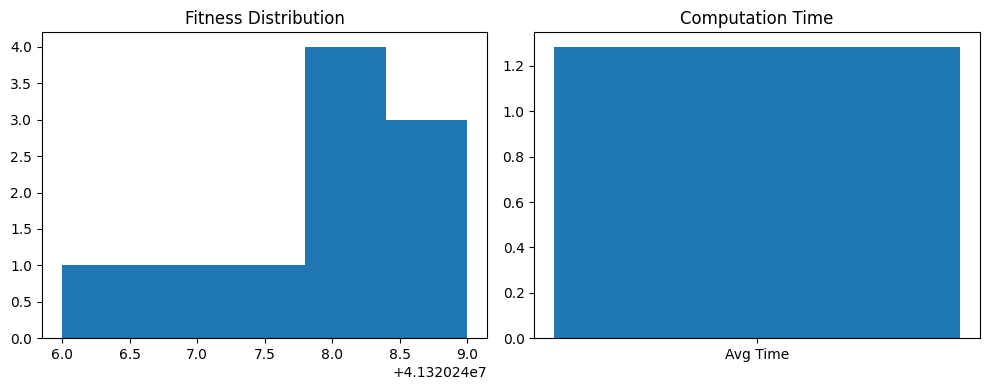

In [19]:
def run_experiments(num_runs: int = 10):
    fitnesses = []
    times = []

    for i in range(num_runs):
        print(f"Run {i+1}/{num_runs}...")
        start = time.time()
        _, fitness = simulated_annealing_enhanced(instance, max_iters=15000)
        elapsed = time.time() - start
        fitnesses.append(fitness)
        times.append(elapsed)

    print("\n=== SUMMARY ===")
    print(f"Best: {min(fitnesses)}")
    print(f"Worst: {max(fitnesses)}")
    print(f"Avg: {np.mean(fitnesses):.2f}")
    print(f"Std: {np.std(fitnesses):.2f}")
    print(f"Avg Time: {np.mean(times):.4f}s")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(fitnesses, bins=5)
    plt.title('Fitness Distribution')
    plt.subplot(1, 2, 2)
    plt.bar(['Avg Time'], [np.mean(times)])
    plt.title('Computation Time')
    plt.tight_layout()
    plt.show()

    return fitnesses, times

# Launch
results, times = run_experiments()